In [133]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [134]:
df = pd.read_csv("heart.csv")

# Dataset

In [135]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# EDA

In [136]:
print("Shape of Data:",df.shape)

Shape of Data: (1025, 14)


In [137]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [139]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Visualization

<Axes: xlabel='age', ylabel='Count'>

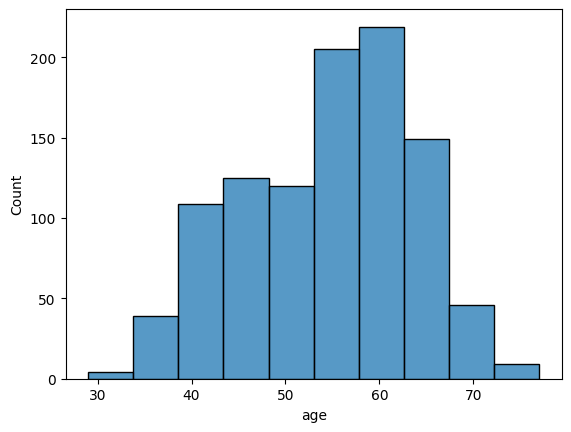

In [140]:
sns.histplot(df['age'], bins=10)

<Axes: xlabel='sex', ylabel='target'>

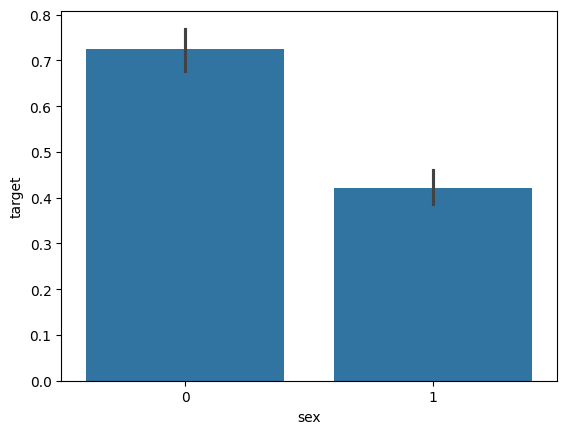

In [141]:
sns.barplot(x = df["sex"], y = df["target"])

<Axes: xlabel='sex', ylabel='count'>

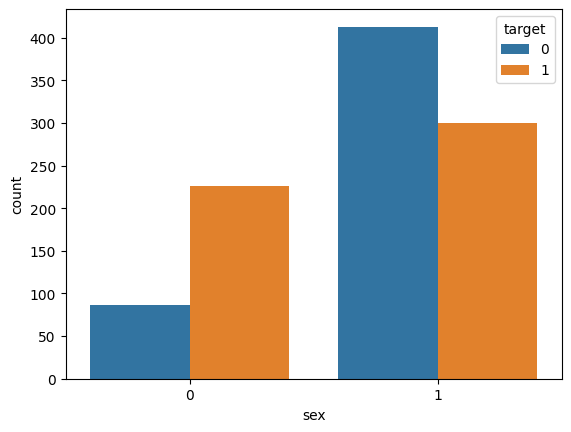

In [142]:
sns.countplot(x = df["sex"], hue = df["target"])

<Axes: xlabel='cp', ylabel='count'>

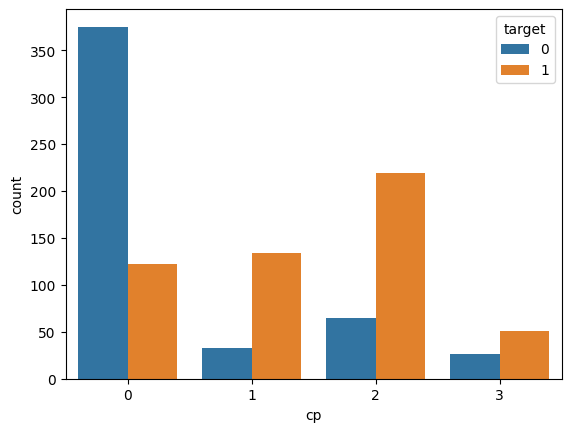

In [143]:
sns.countplot(x = df["cp"], hue = df["target"])


<Axes: ylabel='trestbps'>

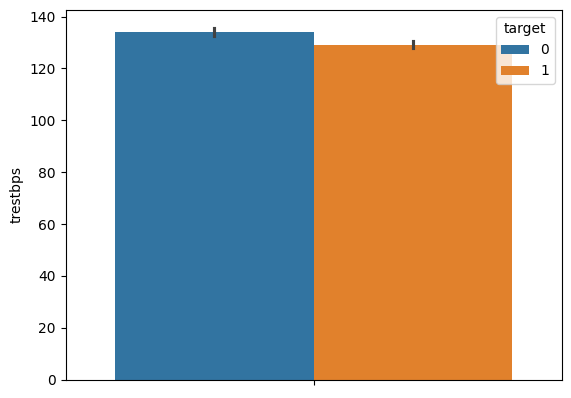

In [144]:
sns.barplot(y = df["trestbps"], hue = df["target"])

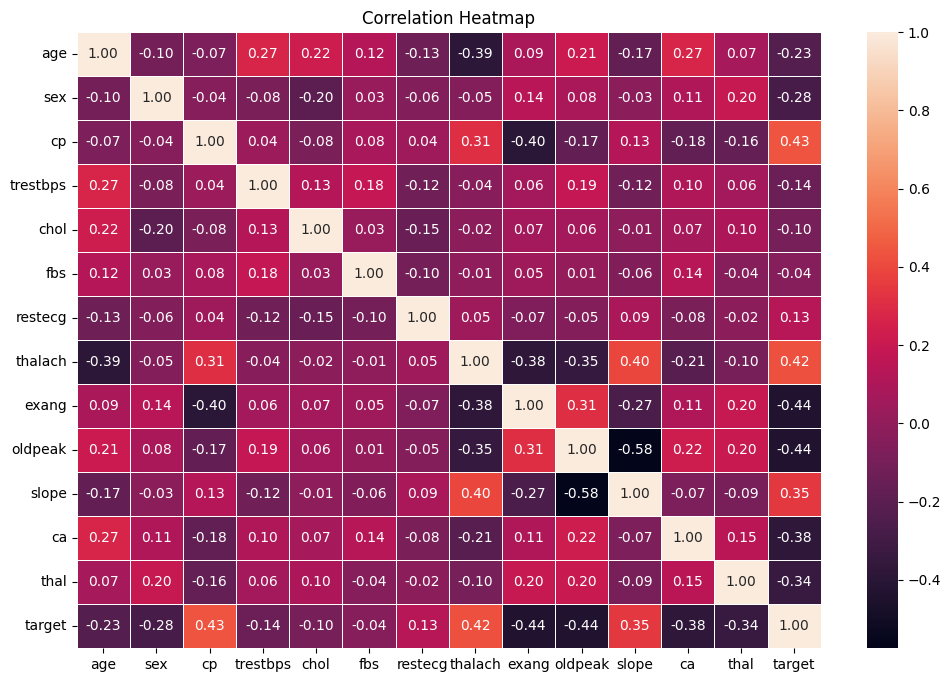

In [145]:
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

# Model Training Using Logistic_Regression

In [146]:
X = df.iloc[:,0:13]
y = df.iloc[:,-1]

In [147]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

In [148]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [149]:
X_train.shape

(820, 13)

In [150]:
from sklearn.linear_model import LogisticRegression

In [151]:
lr = LogisticRegression()

In [152]:
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [153]:
y_pred = lr.predict(X_test)

In [154]:
from sklearn.metrics import accuracy_score

# Accuracy Score

In [155]:
print("Accuracy_Score",accuracy_score(y_test, y_pred))

Accuracy_Score 0.7804878048780488


In [156]:
from sklearn.metrics import confusion_matrix, classification_report

# Classification Report

In [157]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.69      0.76       102
           1       0.74      0.87      0.80       103

    accuracy                           0.78       205
   macro avg       0.79      0.78      0.78       205
weighted avg       0.79      0.78      0.78       205



# Confusion Matrix

In [158]:
print(confusion_matrix(y_test, y_pred))

[[70 32]
 [13 90]]


# Preprocessing

In [159]:
from sklearn.preprocessing import StandardScaler

In [160]:
scaler = StandardScaler()

In [161]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [162]:
X_train_scaled

array([[-0.58584022,  0.65465367,  1.008275  , ...,  1.00526437,
         2.17169136, -0.54519316],
       [ 1.05147737, -1.52752523, -0.91672034, ...,  1.00526437,
        -0.7254674 , -0.54519316],
       [-0.04006769, -1.52752523,  1.008275  , ...,  1.00526437,
        -0.7254674 , -0.54519316],
       ...,
       [-0.36753121,  0.65465367, -0.91672034, ...,  1.00526437,
        -0.7254674 ,  1.11057867],
       [-1.24076726,  0.65465367, -0.91672034, ...,  1.00526437,
        -0.7254674 ,  1.11057867],
       [-0.2583767 ,  0.65465367, -0.91672034, ...,  1.00526437,
         0.24025219, -0.54519316]], shape=(820, 13))

# Model Training Using KNN

In [163]:
from sklearn.neighbors import KNeighborsClassifier

In [164]:
knn = KNeighborsClassifier(n_neighbors=5)

In [165]:
knn.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [166]:
y_pred = knn.predict(X_test_scaled)

# Accuracy Score

In [167]:
print("Accuracy Score",accuracy_score(y_test,y_pred))

Accuracy Score 0.8341463414634146


# Cross Validation

In [168]:
from sklearn.model_selection import cross_val_score

In [169]:
X_scaled =  scaler.fit_transform(X)

In [170]:
scores = cross_val_score(knn, X_scaled, y, cv=5, scoring="accuracy")

In [171]:
scores

array([0.86341463, 0.83902439, 0.81463415, 0.83414634, 0.81463415])

In [172]:
scores.mean()

np.float64(0.8331707317073171)

# Classificatin Report

In [173]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82       102
           1       0.80      0.89      0.84       103

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.84      0.83      0.83       205



# Confusion Matrix

In [174]:
print(confusion_matrix(y_test, y_pred))

[[79 23]
 [11 92]]


# Again Preprocessing (One Hot Encoding)

In [175]:
cat_cols = ['cp', 'restecg', 'slope', 'thal']

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

df_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,0,False,False,False,True,False,False,True,False,False,True
1,53,1,140,203,1,155,1,3.1,0,0,False,False,False,False,False,False,False,False,False,True
2,70,1,145,174,0,125,1,2.6,0,0,False,False,False,True,False,False,False,False,False,True
3,61,1,148,203,0,161,0,0.0,1,0,False,False,False,True,False,False,True,False,False,True
4,62,0,138,294,1,106,0,1.9,3,0,False,False,False,True,False,True,False,False,True,False


In [176]:
df_encoded = df_encoded.astype(int)

In [177]:
df_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1,2,0,0,0,0,1,0,0,1,0,0,1
1,53,1,140,203,1,155,1,3,0,0,0,0,0,0,0,0,0,0,0,1
2,70,1,145,174,0,125,1,2,0,0,0,0,0,1,0,0,0,0,0,1
3,61,1,148,203,0,161,0,0,1,0,0,0,0,1,0,0,1,0,0,1
4,62,0,138,294,1,106,0,1,3,0,0,0,0,1,0,1,0,0,1,0


In [178]:
numerical_col = ["age", "trestbps", "chol", "thalach"]
df_encoded[numerical_col] = scaler.fit_transform(df_encoded[numerical_col])
df_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,-0.268437,1,-0.377636,-0.659332,0,0.821321,0,1,2,0,0,0,0,1,0,0,1,0,0,1
1,-0.158157,1,0.479107,-0.833861,1,0.255968,1,3,0,0,0,0,0,0,0,0,0,0,0,1
2,1.716595,1,0.764688,-1.396233,0,-1.048692,1,2,0,0,0,0,0,1,0,0,0,0,0,1
3,0.724079,1,0.936037,-0.833861,0,0.516900,0,0,1,0,0,0,0,1,0,0,1,0,0,1
4,0.834359,0,0.364875,0.930822,1,-1.874977,0,1,3,0,0,0,0,1,0,1,0,0,1,0


In [179]:
df_encoded.shape

(1025, 20)

In [180]:
X_encoded = df_encoded.drop(columns=["target"])
y_encoded = df_encoded["target"]

In [181]:
X_encoded

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,-0.268437,1,-0.377636,-0.659332,0,0.821321,0,1,2,0,0,0,1,0,0,1,0,0,1
1,-0.158157,1,0.479107,-0.833861,1,0.255968,1,3,0,0,0,0,0,0,0,0,0,0,1
2,1.716595,1,0.764688,-1.396233,0,-1.048692,1,2,0,0,0,0,1,0,0,0,0,0,1
3,0.724079,1,0.936037,-0.833861,0,0.516900,0,0,1,0,0,0,1,0,0,1,0,0,1
4,0.834359,0,0.364875,0.930822,1,-1.874977,0,1,3,0,0,0,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,0.503520,1,0.479107,-0.484803,0,0.647366,1,0,0,1,0,0,1,0,0,1,0,1,0
1021,0.613800,1,-0.377636,0.232705,0,-0.352873,1,2,1,0,0,0,0,0,1,0,0,0,1
1022,-0.819834,1,-1.234378,0.562371,0,-1.353113,1,1,1,0,0,0,0,0,1,0,0,1,0
1023,-0.488996,0,-1.234378,0.155137,0,0.429923,0,0,0,0,0,0,0,0,0,1,0,1,0


In [182]:
y_encoded

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

# Model Training Using KNN with Encoded Dataset

In [183]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded,y_encoded, test_size=0.2, random_state=45)

In [184]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [185]:
knn_2 = KNeighborsClassifier(n_neighbors=5)

In [186]:
knn_2.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [187]:
y_pred = knn_2.predict(X_test)

# Accuracy Score

In [188]:
accuracy_score(y_test,y_pred)

0.824390243902439